In [140]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# ========================
# 0. ĐỌC DỮ LIỆU VÀ EDA CƠ BẢN
# ========================
# Bước đầu tiên: Đọc data và kiểm tra tổng quan
df = pd.read_csv('vietnam_housing_dataset - Copy.csv')  # thay bằng đường dẫn file thực tế của bạn

df.head(10)

,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ Chí Minh",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90
5,"Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên",91.0,7.0,13.0,Tây - Bắc,NaN,NaN,NaN,NaN,Have certificate,NaN,9.80
6,"Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên",64.0,4.0,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.20
7,"Dự án Him Lam Thường Tín, Huyện Thường Tín, Hà Nội",74.0,5.0,18.0,Nam,Nam,5.0,4.0,5.0,Have certificate,NaN,9.90
8,"Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên",48.0,NaN,NaN,NaN,NaN,5.0,6.0,NaN,NaN,Basic,5.70
9,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên",91.0,7.0,NaN,NaN,NaN,5.0,NaN,NaN,Have certificate,NaN,9.50


In [141]:
# Hiển thị tối đa số hàng (None là không giới hạn)
pd.set_option('display.max_rows', None)

# Hiển thị tối đa số cột
pd.set_option('display.max_columns', None)

# Hiển thị đầy đủ nội dung trong mỗi ô (không bị cắt bớt chữ)
pd.set_option('display.max_colwidth', None)

# Đảm bảo bảng không bị xuống dòng khi quá rộng
pd.set_option('display.expand_frame_repr', False)

print("\n=== 1. Kiểm tra shape ban đầu ===")
print(f"Shape: {df.shape}")

print("\n=== 2. Info dữ liệu (kiểu dữ liệu, missing) ===")
print(df.info())

print("\n=== 3. Describe numerical features (thống kê cơ bản) ===")
print(df.describe())


=== 1. Kiểm tra shape ban đầu ===
Shape: (30229, 12)

=== 2. Info dữ liệu (kiểu dữ liệu, missing) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  object 
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   object 
 5   Balcony direction  5246 non-null   object 
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  object 
 10  Furniture state    16110 non-null  object 
 11  Price              30229 non-null  float64
dtypes: float64(7), object(5)
memory usage: 2.8+ MB
None

=== 3. Describe numerical features (thống kê cơ bản) ===
 

In [142]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

In [143]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['area'] = pd.to_numeric(df['area'], errors='coerce')
# Các cột numerical khác
numerical_cols = ['price', 'area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']
for col in numerical_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

categorical_cols = ['house_direction', 'legal_status', 'furniture_state', 'address']

In [144]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)

print("\n=== 5. Missing values percentage ===")
for col, pct in missing.items():
    print(f"{col}: {pct:.2f}%")

#=> loại bỏ balcony_direction vì missing quá nhiều, và có thể không quan trọng bằng các feature khác


=== 5. Missing values percentage ===
balcony_direction: 82.65%
house_direction: 70.26%
furniture_state: 46.71%
access_road: 43.99%
frontage: 38.25%
bathrooms: 23.40%
bedrooms: 17.08%
legal_status: 14.91%
floors: 11.92%


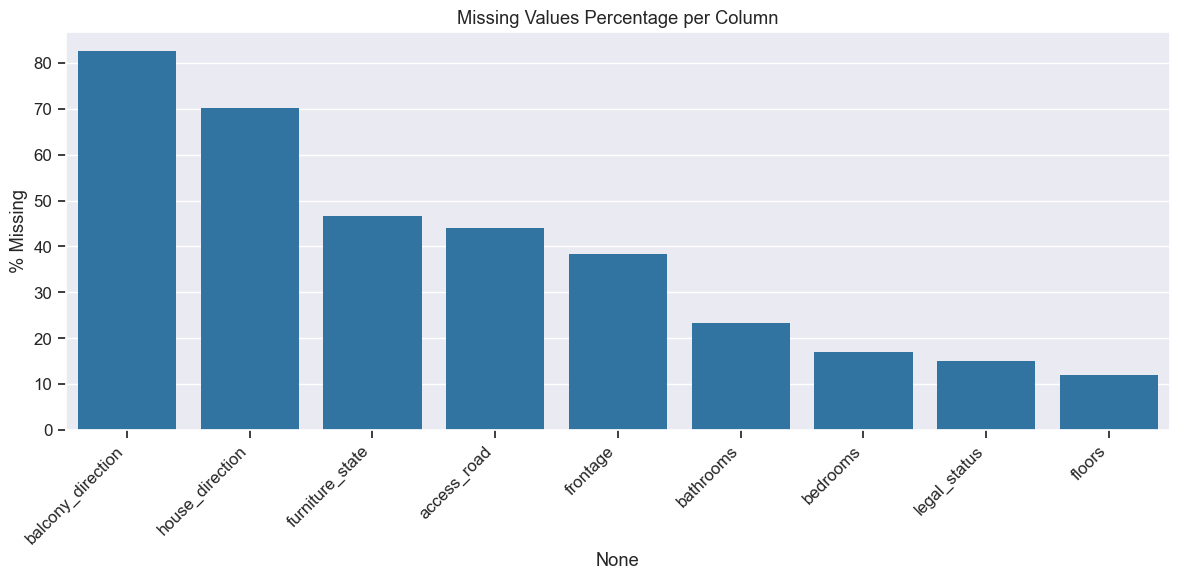

In [145]:
if not missing.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(x=missing.index, y=missing.values)
    plt.xticks(rotation=45, ha='right')
    plt.title('Missing Values Percentage per Column')
    plt.ylabel('% Missing')
    plt.tight_layout()
    plt.show()

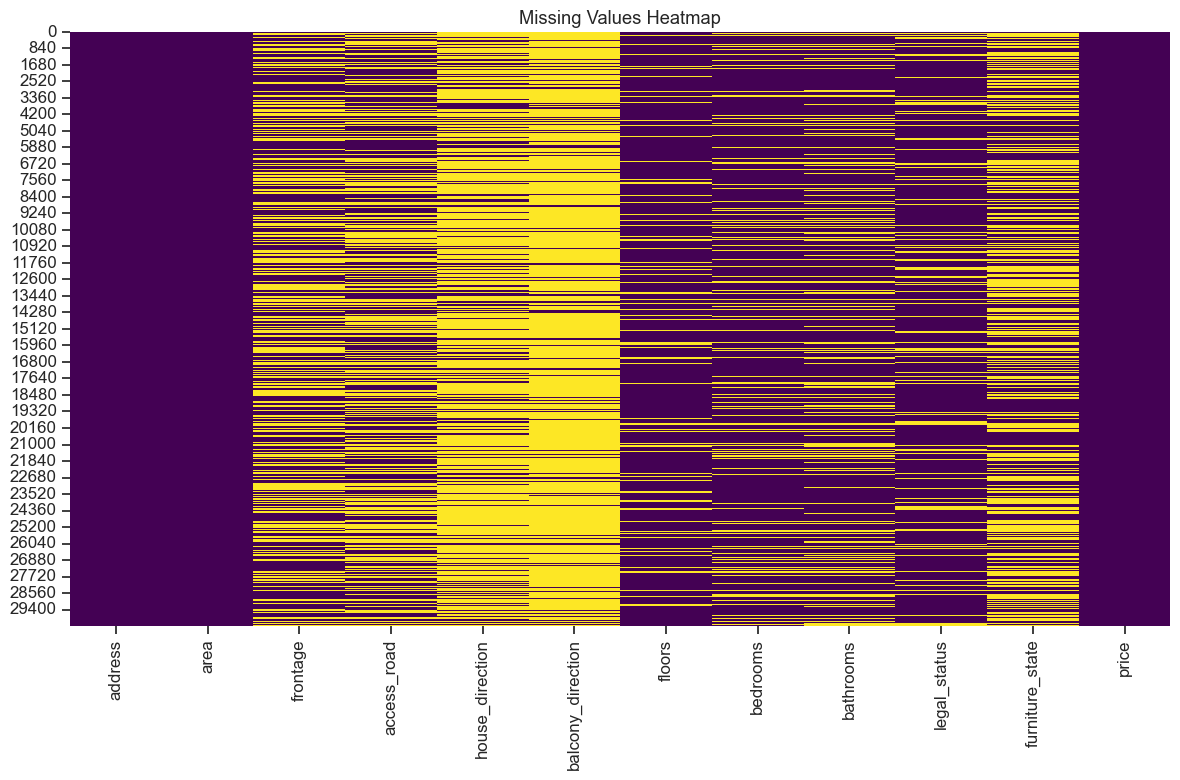

In [146]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

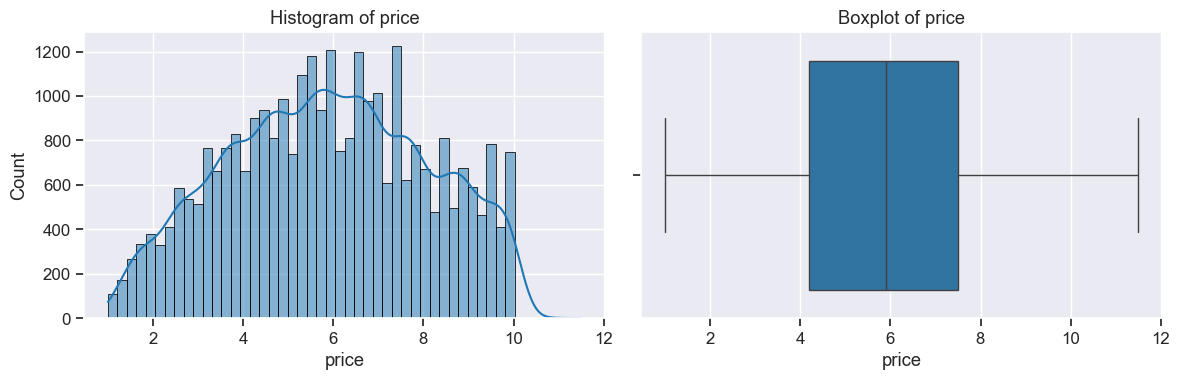

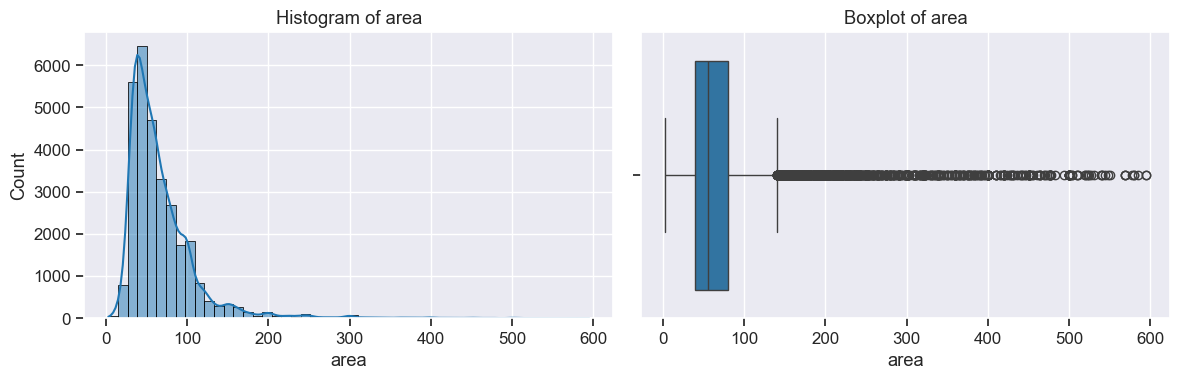

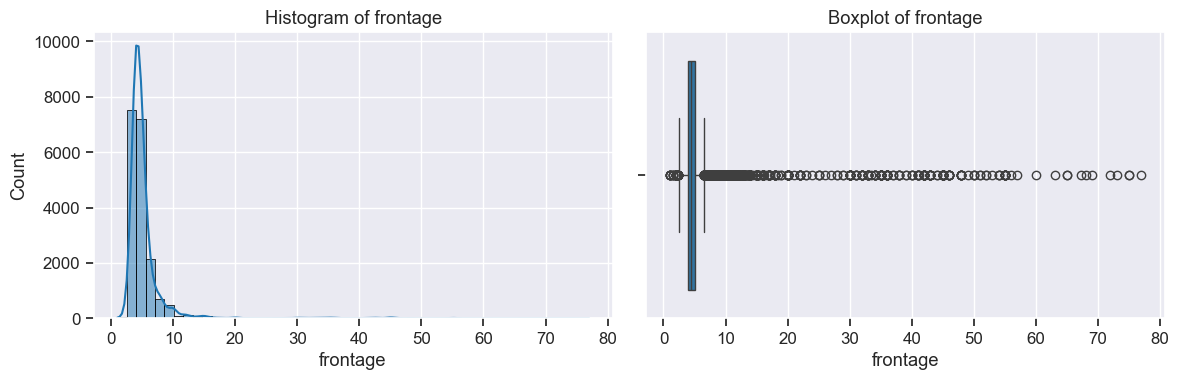

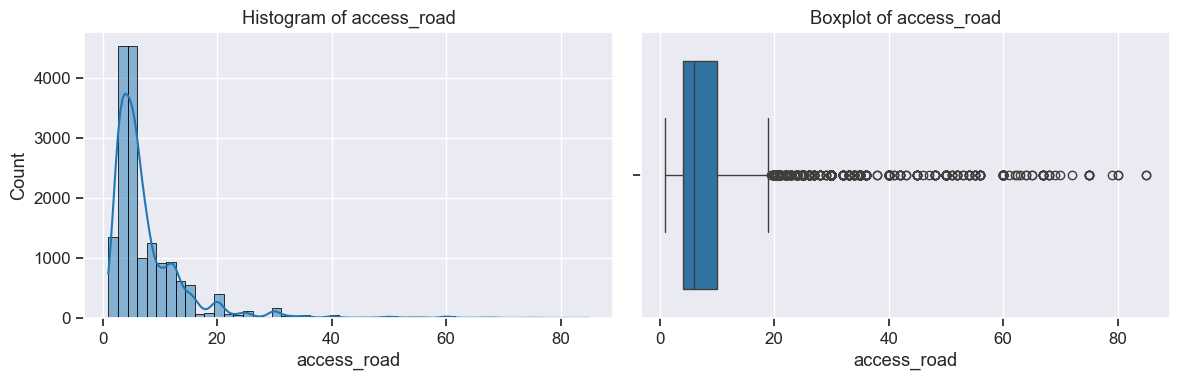

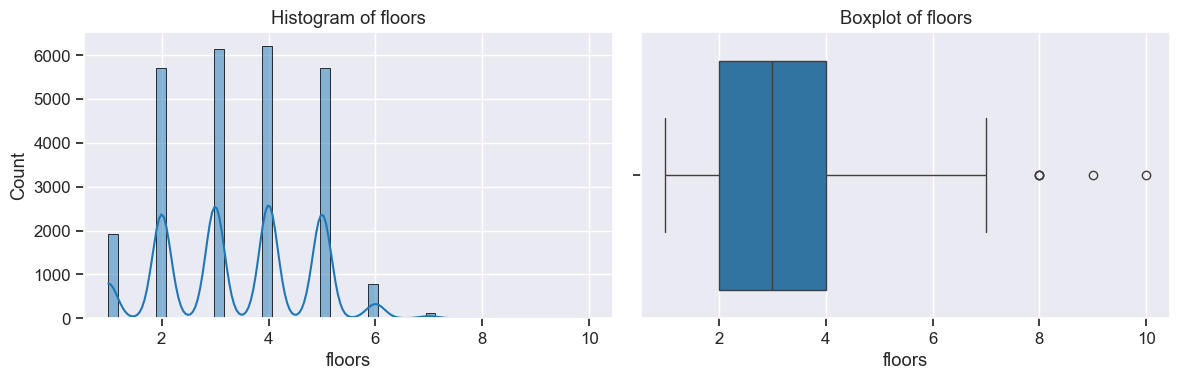

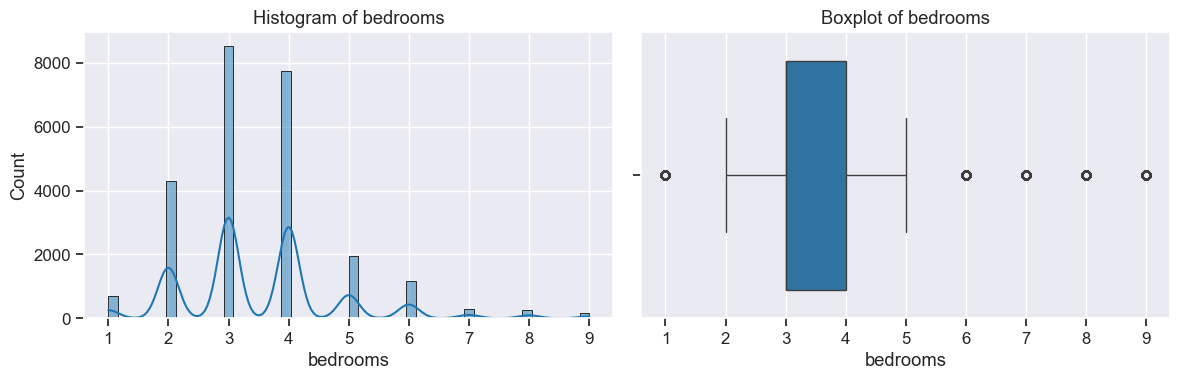

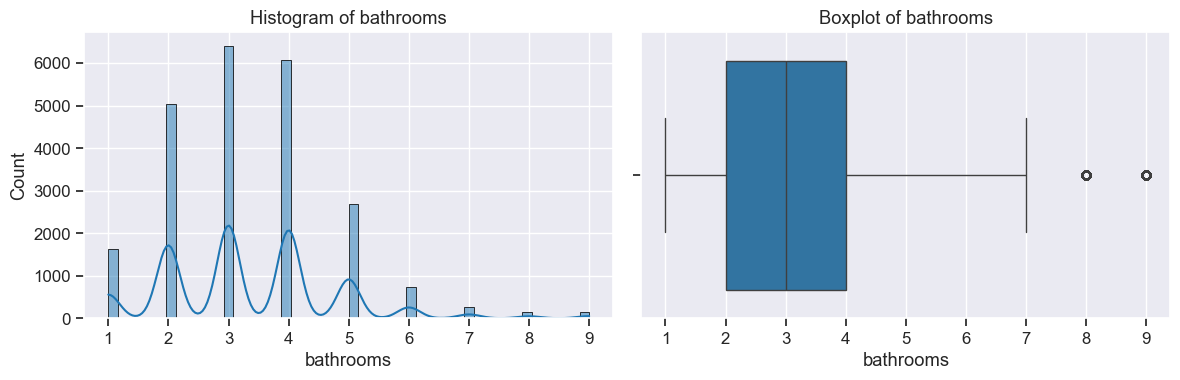

In [147]:
for col in numerical_cols:
    if col in df.columns:
        plt.figure(figsize=(12, 4))
        
        # Histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col].dropna(), kde=True, bins=50)
        plt.title(f'Histogram of {col}')
        
        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col].dropna())
        plt.title(f'Boxplot of {col}')
        
        plt.tight_layout()
        plt.show()


=== Value counts for house_direction (top 10) ===
house_direction
Đông - Nam    1916
Đông - Bắc    1180
Tây - Nam     1152
Tây - Bắc     1125
Nam           1042
Đông           952
Bắc            832
Tây            791
Name: count, dtype: int64


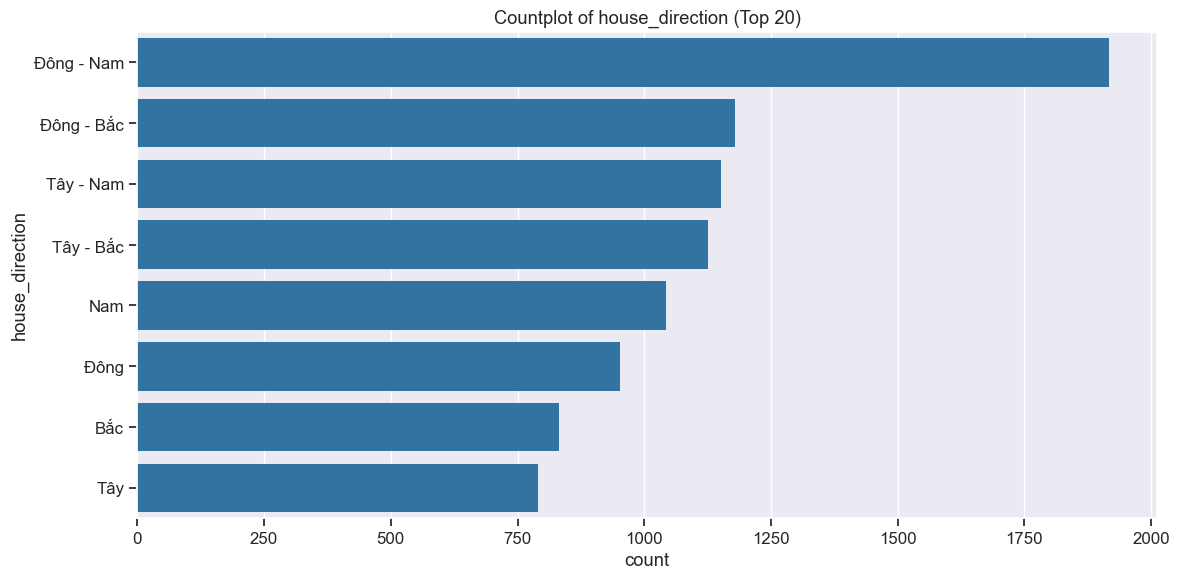


=== Value counts for legal_status (top 10) ===
legal_status
Have certificate    24774
Sale contract         949
Name: count, dtype: int64


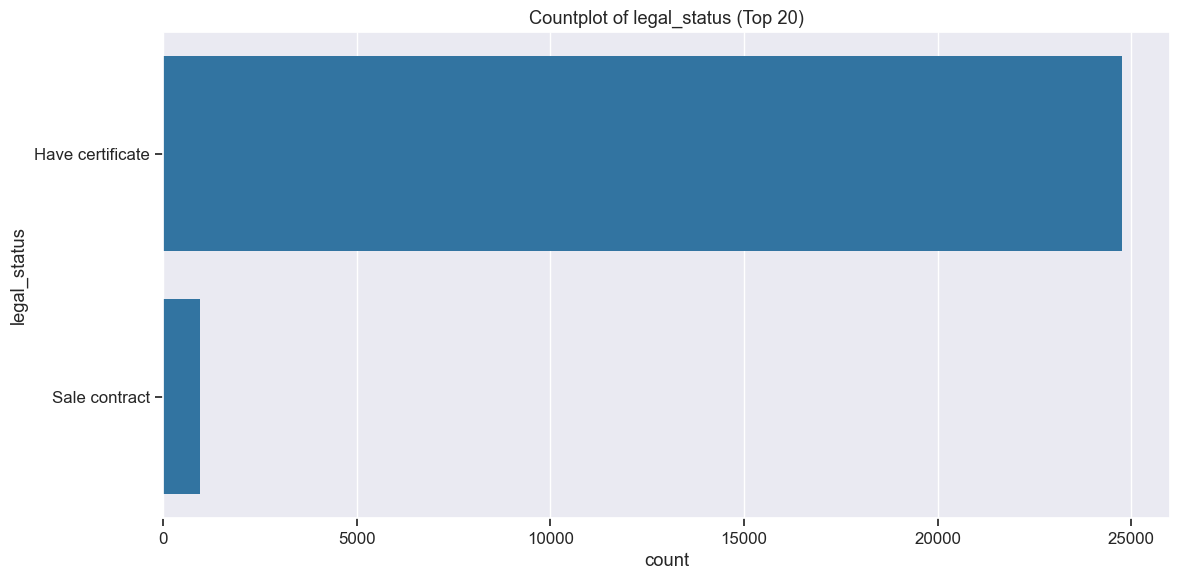


=== Value counts for furniture_state (top 10) ===
furniture_state
Full     10591
Basic     5519
Name: count, dtype: int64


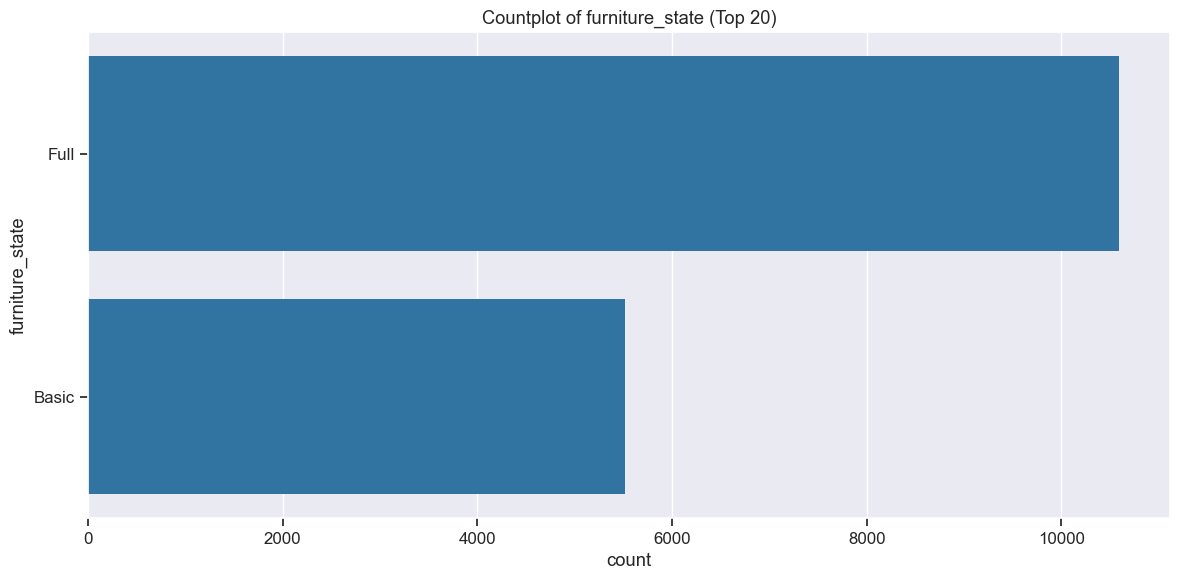


=== Value counts for address (top 10) ===
address
Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên               187
Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên                129
Đường Trương Định, Phường Trương Định, Hai Bà Trưng, Hà Nội                                84
Đường Ngọc Thụy, Phường Ngọc Thụy, Long Biên, Hà Nội                                       77
Đường Minh Khai, Phường Minh Khai, Hai Bà Trưng, Hà Nội                                    74
Dự án Waterpoint, Đường Tỉnh lộ 824, Xã An Thạnh, Bến Lức, Long An                         71
Đường Xuân Đỉnh, Phường Xuân Đỉnh, Bắc Từ Liêm, Hà Nội                                     68
Dự án NovaWorld Phan Thiết, Đường Lạc Long Quân, Xã Tiến Thành, Phan Thiết, Bình Thuận     63
Đường Huỳnh Tấn Phát, Thị trấn Nhà Bè, Nhà Bè, Hồ Chí Minh                                 63
Phố Thái Hà, Phường Trung Liệt, Đống Đa, Hà Nội                                           61
Name: cou

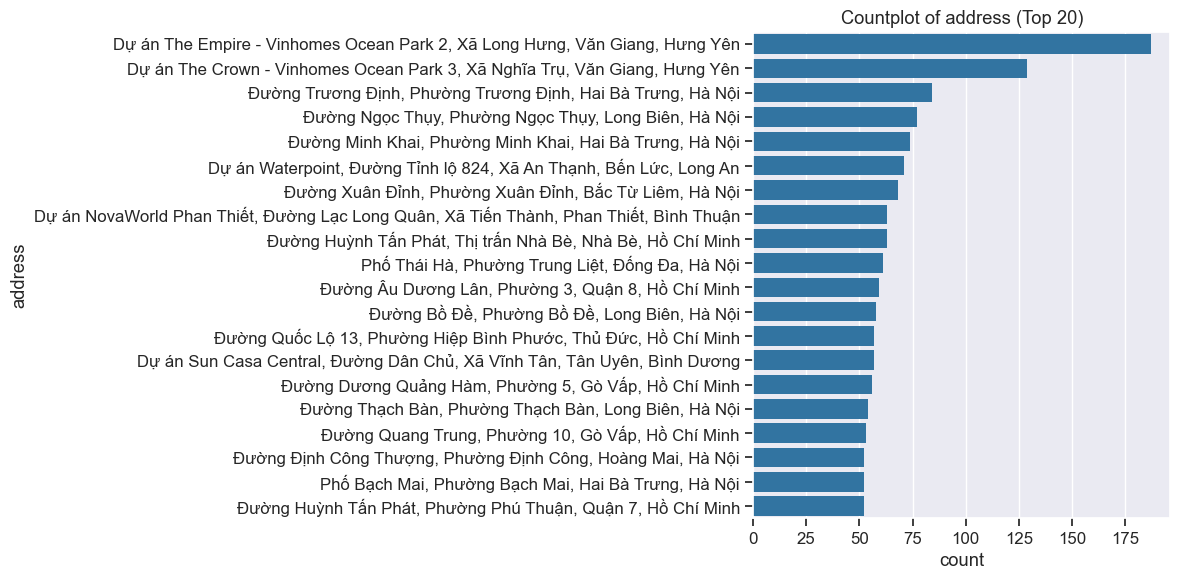

In [148]:
# 3. PHÂN TÍCH CATEGORICAL FEATURES
# ========================
# Value counts và bar plots để xem phân bố
for col in categorical_cols:
    if col in df.columns:
        print(f"\n=== Value counts for {col} (top 10) ===")
        print(df[col].value_counts().head(10))
        
        plt.figure(figsize=(12, 6))
        sns.countplot(y=df[col], order=df[col].value_counts().head(20).index)
        plt.title(f'Countplot of {col} (Top 20)')
        plt.tight_layout()
        plt.show()

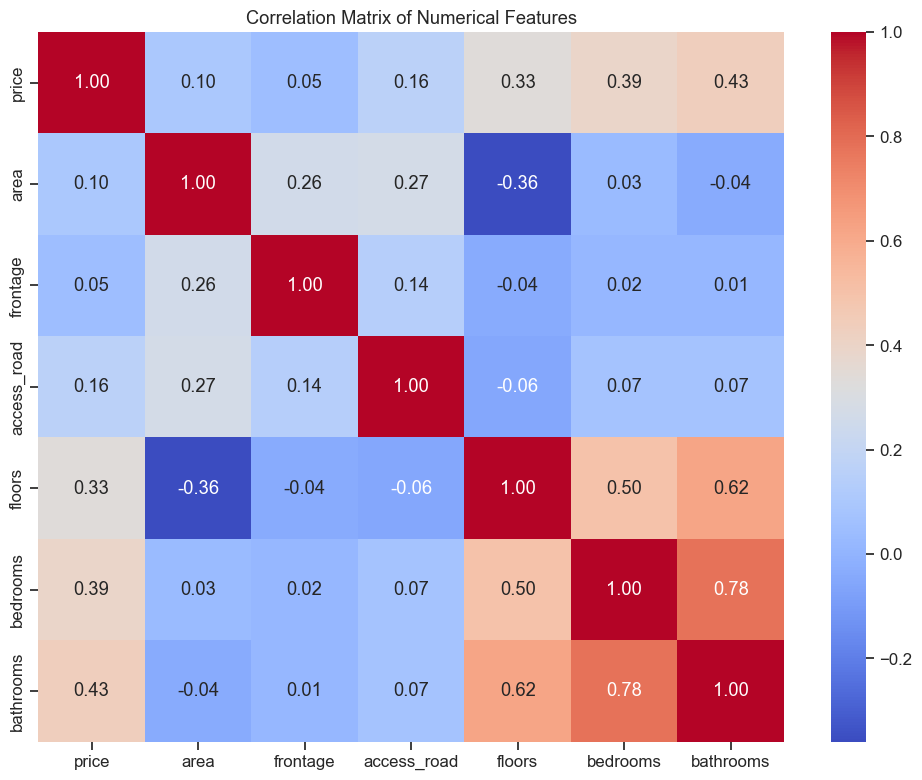

In [149]:
# 4. CORRELATION ANALYSIS
# ========================
# Correlation matrix để xem mối quan hệ giữa features
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

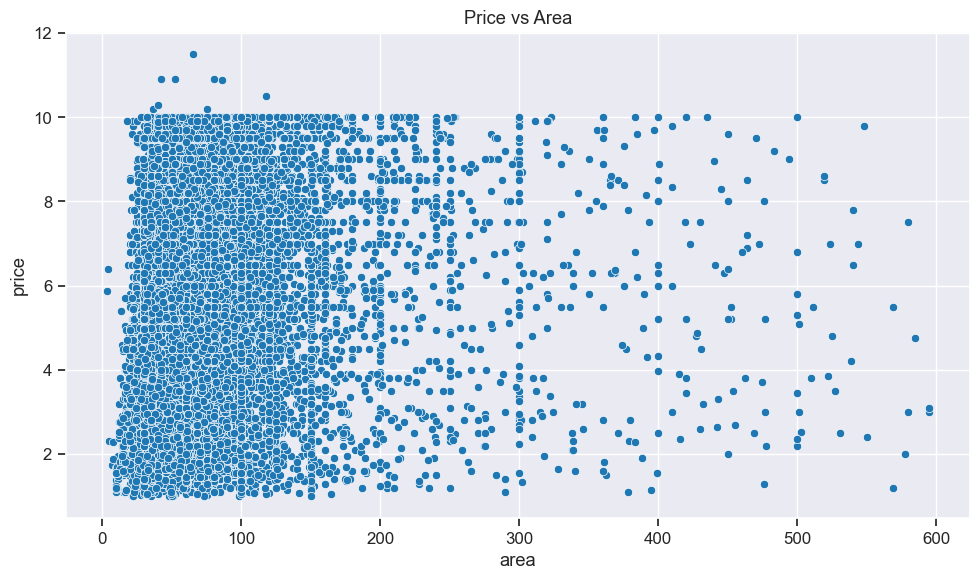

In [150]:
# 5. BIVARIATE ANALYSIS (ví dụ: price vs other features)
# ========================
# Scatter plot price vs area
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
plt.title('Price vs Area')
plt.tight_layout()
plt.show()

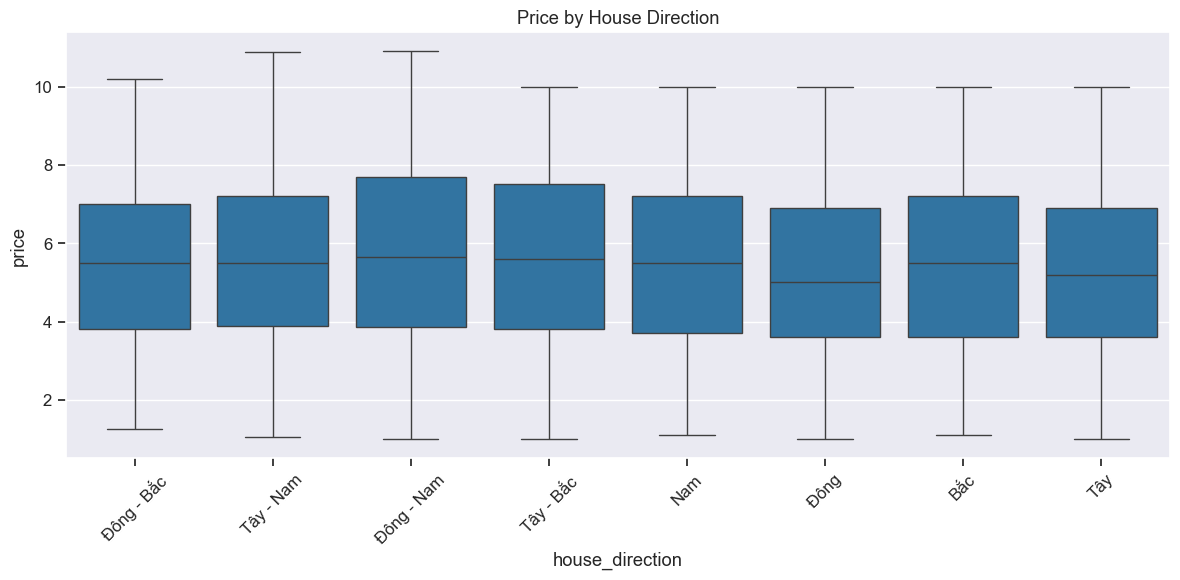

In [151]:
# Boxplot price by house_direction
if 'house_direction' in df.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='house_direction', y='price', data=df)
    plt.xticks(rotation=45)
    plt.title('Price by House Direction')
    plt.tight_layout()
    plt.show()

# Lý do: Thấy direction tốt (Nam, Đông Nam) có giá cao hơn, nên tạo feature is_good_direction

In [152]:
# === BƯỚC 6.1: XỬ LÝ OUTLIERS DỰA TRÊN ĐƠN GIÁ (PRICE_PER_M2) ===
# Thêm bước này ngay sau khi bạn đã dropna 'price' và 'area'

df = df[(df['price'] > 0) & (df['area'] > 0)]
df['price_per_m2'] = df['price'] / df['area']

# Tính toán ngưỡng quantile cho đơn giá
# Có thể chặt chẽ hơn, ví dụ: 0.02 và 0.98
lower_bound_ppm = df['price_per_m2'].quantile(0.02)
upper_bound_ppm = df['price_per_m2'].quantile(0.98)

# Giữ lại những dữ liệu có đơn giá trong khoảng hợp lý
df = df[(df['price_per_m2'] >= lower_bound_ppm) & (df['price_per_m2'] <= upper_bound_ppm)]

# Sau khi lọc xong, có thể xóa cột tạm này đi
df = df.drop(columns=['price_per_m2'])

print(f"\nSau khi lọc outlier theo đơn giá: {df.shape[0]} dòng")

# Giữ lại các bước clip của bạn cho price và area để xử lý các giá trị cực đoan còn sót lại
lower_p, upper_p = df['price'].quantile([0.01, 0.99])
df['price'] = df['price'].clip(lower_p, upper_p)

lower_a, upper_a = df['area'].quantile([0.005, 0.995])
df['area'] = df['area'].clip(lower_a, upper_a)

print(f"Sau clip outlier cuối cùng: {df.shape[0]} dòng")


Sau khi lọc outlier theo đơn giá: 29024 dòng
Sau clip outlier cuối cùng: 29024 dòng


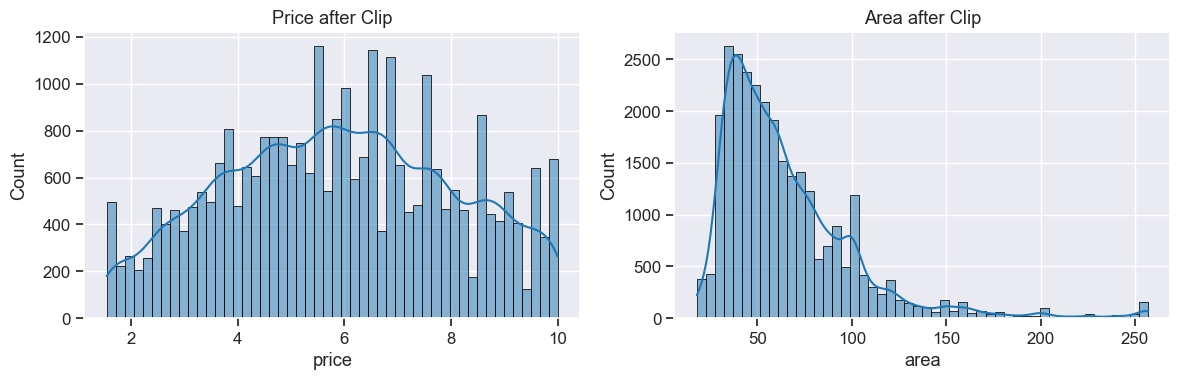

In [153]:
# Plot lại price và area sau clip để check
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Price after Clip')

plt.subplot(1, 2, 2)
sns.histplot(df['area'], kde=True, bins=50)
plt.title('Area after Clip')
plt.tight_layout()
plt.show()

In [154]:
# ========================
# 7. EXTRACT CITY & DISTRICT (kết hợp tốt nhất: city substring + fallback parts cuối + district duyệt toàn bộ + normalize mạnh)
# ========================
def extract_district_city_v2(address):
    if pd.isna(address) or not isinstance(address, str) or not address.strip():
        return 'Other', 'Other'
   
    # Làm sạch address
    addr = address.strip()
    addr = addr.rstrip('.').strip()
    addr = re.sub(r'\s*,\s*', ', ', addr)
    addr = re.sub(r'\s+', ' ', addr)
    address_lower = addr.lower()
   
    # City mapping (substring mạnh - giữ nguyên từ code của bạn)
    city_map = {
        'hồ chí minh': 'HCM', 'tp.hồ chí minh': 'HCM', 'tphcm': 'HCM', 'hcm': 'HCM',
        'tp hồ chí minh': 'HCM', 'tp. hồ chí minh': 'HCM', 'hồ chí minh': 'HCM', 'hồ chí minh.': 'HCM',
        'hà nội': 'HN', 'thành phố hà nội': 'HN', 'hn': 'HN', 'hà nội': 'HN', 'hà nội.': 'HN',
        'hưng yên': 'HY', 'hưng yên.': 'HY',
        'thái bình': 'HY',
        'bình dương': 'BD', 'bình dương.': 'BD',
        'đà nẵng': 'ĐN', 'đn': 'ĐN', 'đà nẵng.': 'ĐN',
        'long an': 'LA', 'long an.': 'LA',
        'đồng nai': 'Đồng Nai', 'đồng nai.': 'Đồng Nai',
        'bà rịa vũng tàu': 'BRVT', 'bà rịa vũng tàu.': 'BRVT',
        'quảng ninh': 'QN', 'quảng ninh.': 'QN',
        'phú thọ': 'PT', 'vĩnh phúc': 'PT', 'hòa bình': 'PT',
        'hải phòng': 'HP', 'hải dương': 'HP', 'hải phòng.': 'HP',
        'khánh hòa': 'KH', 'khánh hòa.': 'KH',
        'kiên giang': 'KG', 'kiên giang.': 'KG',
        'bình thuận': 'BT', 'bình thuận.': 'BT',
        'thanh hóa': 'TH', 'thanh hóa.': 'TH',
        'cần thơ': 'CT', 'cần thơ.': 'CT',
        # Fallback sáp nhập
        'hà giang': 'tuyên quang',
        'yên bái': 'lào cai',
        'bắc kạn': 'thái nguyên',
        'bắc giang': 'bắc ninh',
        'hà nam': 'ninh bình',
        'nam định': 'ninh bình',
    }
   
    city = 'Other'
    for k, v in city_map.items():
        if k in address_lower:
            city = v
            break
   
    # THÊM: Nếu vẫn 'Other' → lấy phần cuối cùng (giống code 1)
    if city == 'Other':
        parts = [p.strip() for p in addr.split(',') if p.strip()]
        if parts:
            last_part = parts[-1].strip()
            last_lower = last_part.lower()
            
            # Ưu tiên match lại với city_map (vì có thể viết hoa khác)
            for k, v in city_map.items():
                if k in last_lower:
                    city = v
                    break
            
            # Nếu vẫn không match → lấy nguyên last_part làm city (title case)
            if city == 'Other':
                city = last_part.title()
   
    # District - giữ nguyên logic duyệt toàn bộ + normalize mạnh của bạn
    district_keywords = ['quận ', 'huyện ', 'thị trấn ', 'phường ', 'xã ', 'thị xã ', 'tp.', 'thành phố ', 'tp ']
    district = 'Other'
   
    parts = [p.strip() for p in addr.split(',') if p.strip()]
   
    for part in parts:
        part_lower = part.lower()
       
        if any(kw in part_lower for kw in district_keywords):
            cleaned = re.sub(r'^(quận|huyện|thị xã|thành phố|tp\.|tp )\s+', '', part, flags=re.IGNORECASE).strip()
            district = cleaned.title()
            break
        elif any(d in part_lower for d in [
            'gò vấp', 'bình thạnh', 'quận 7', 'thủ đức', 'long biên', 'cầu giấy', 'đống đa', 'thanh xuân',
            'văn giang', 'nha trang', 'biên hòa', 'thủ dầu một', 'thuận an', 'vũng tàu', 'phan thiết', 'dĩ an', 'tân uyên'
        ]):
            district = part.title()
            break
   
    # Normalize district (map biến thể)
    district_normalize = {
        'long biên': 'Long Biên', 'quận long biên': 'Long Biên',
        'quận tân bình': 'Tân Bình', 'tân bình': 'Tân Bình',
        'quận bình tân': 'Bình Tân', 'bình tân': 'Bình Tân',
        'huyện văn giang': 'Văn Giang', 'văn giang': 'Văn Giang',
        'thành phố nha trang': 'Nha Trang', 'nha trang': 'Nha Trang',
        'thành phố biên hòa': 'Biên Hòa', 'biên hòa': 'Biên Hòa',
        'thành phố thủ dầu một': 'Thủ Dầu Một', 'thủ dầu một': 'Thủ Dầu Một',
        'thành phố thuận an': 'Thuận An', 'thuận an': 'Thuận An',
        'thành phố tân uyên': 'Tân Uyên', 'tân uyên': 'Tân Uyên',
        'thành phố vũng tàu': 'Vũng Tàu', 'vũng tàu': 'Vũng Tàu',
        'thành phố phan thiết': 'Phan Thiết', 'phan thiết': 'Phan Thiết',
        'thành phố dĩ an': 'Dĩ An', 'dĩ an': 'Dĩ An',
        'quận 1': 'Quận 1',
        'quận 2': 'Quận 2',
        'quận 3': 'Quận 3',
        'quận 4': 'Quận 4',
        'quận 5': 'Quận 5',
        'quận 6': 'Quận 6',
        'quận 7': 'Quận 7',
        'quận 8': 'Quận 8',
        'quận 9': 'Quận 9',
        'quận 10': 'Quận 10',
        'quận 11': 'Quận 11',
        'quận 12': 'Quận 12',
    }
   
    district_lower_clean = re.sub(r'^(quận|huyện|thị xã|thành phố)\s+', '', district.lower())
    for k, v in district_normalize.items():
        if k in district_lower_clean:
            district = v
            break
   
    # Rule dự án
    if district == 'Other' and 'dự án' in address_lower:
        if 'ocean park' in address_lower or 'vinhomes ocean' in address_lower:
            district = 'Văn Giang'
        elif 'grand park' in address_lower or 'vinhomes grand park' in address_lower:
            district = 'Quận 9'
   
    # Clean cuối cùng cho district
    district = re.sub(r'^(Quận|Huyện|Thành phố|Tp\.|Thị Xã)\s+', '', district, flags=re.IGNORECASE).strip().title()
   
    return city, district


# Áp dụng (giữ nguyên)
df['city'], df['district'] = zip(*df['address'].apply(extract_district_city_v2))
df = df.drop('address', axis=1, errors='ignore')

# Kiểm tra (giữ nguyên phần print của bạn)
print("\n=== Phân bố city sau extract ===")
print(df['city'].value_counts().head(30))
print("\n=== Số 'Other' city:", (df['city'] == 'Other').sum(), f"({(df['city'] == 'Other').mean():.2%})")
print("\n=== Phân bố district sau extract ===")
print(df['district'].value_counts().head(40))
print("\n=== Số 'Other' district:", (df['district'] == 'Other').sum(), f"({(df['district'] == 'Other').mean():.2%})")
print("\n=== Tất cả district unique ===")
print(sorted(df['district'].unique()))


=== Phân bố city sau extract ===
city
HCM               11582
HN                10009
BD                 1581
ĐN                 1431
HP                  771
Đồng Nai            755
KH                  663
HY                  427
LA                  284
BRVT                209
Bắc Ninh            166
BT                  123
QN                  109
TH                  109
CT                  108
Lâm Đồng             84
PT                   82
KG                   76
Đắk Lắk              63
ninh bình            53
Bình Định            42
Quảng Nam            37
Thừa Thiên Huế       29
Nghệ An              28
Lào Cai              28
bắc ninh             24
Thái Nguyên          19
Tiền Giang           15
Ninh Thuận           13
Quảng Trị            12
Name: count, dtype: int64

=== Số 'Other' city: 0 (0.00%)

=== Phân bố district sau extract ===
district
Phường 5                  437
Phường 11                 431
Phường 12                 425
Phường 14                 376
Phường 15       

In [155]:
# Plot phân bố city và district sau extract
print("\n=== Phân bố City sau extract ===")
print(df['city'].value_counts().head(15))


=== Phân bố City sau extract ===
city
HCM         11582
HN          10009
BD           1581
ĐN           1431
HP            771
Đồng Nai      755
KH            663
HY            427
LA            284
BRVT          209
Bắc Ninh      166
BT            123
QN            109
TH            109
CT            108
Name: count, dtype: int64


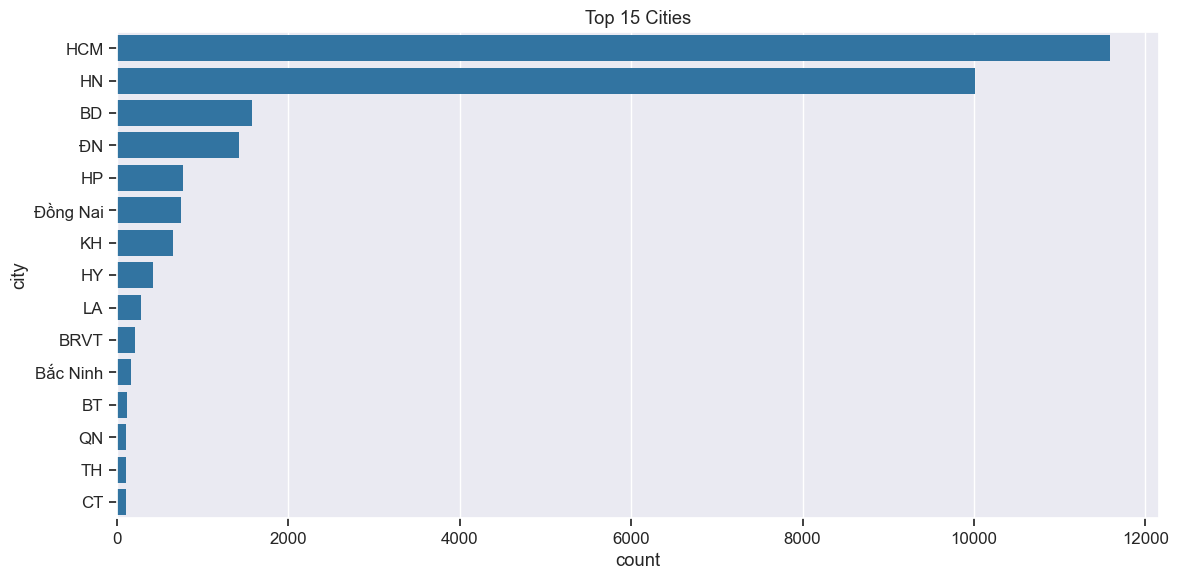

In [156]:
plt.figure(figsize=(12, 6))
sns.countplot(y=df['city'], order=df['city'].value_counts().head(15).index)
plt.title('Top 15 Cities')
plt.tight_layout()
plt.show()


=== Phân bố District sau extract (top 20) ===
district
Phường 5                  437
Phường 11                 431
Phường 12                 425
Phường 14                 376
Phường 15                 333
Phường 13                 327
Phường 3                  324
Phường 10                 317
Xã Long Hưng              287
Phường 4                  253
Phường 7                  242
Phường 8                  231
Phường 6                  229
Phường 9                  229
Phường Tân Quý            222
Phường Phú Hữu            210
Phường 1                  205
Phường Tân Đông Hiệp      205
Phường Thạch Bàn          202
Phường Bình Hưng Hòa A    201
Name: count, dtype: int64


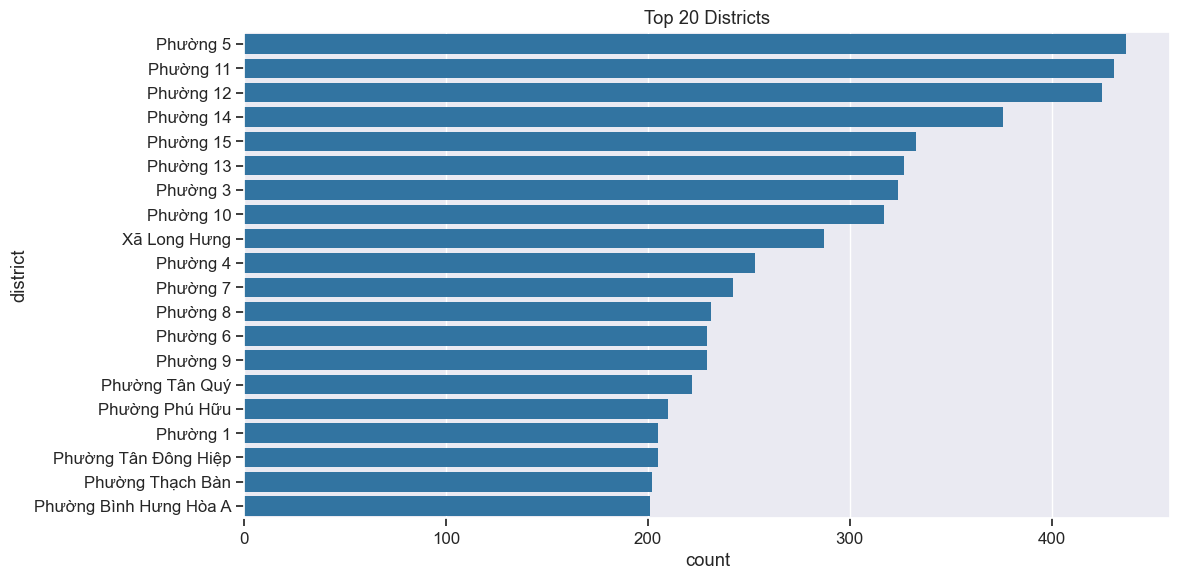

In [157]:
print("\n=== Phân bố District sau extract (top 20) ===")
print(df['district'].value_counts().head(20))

plt.figure(figsize=(12, 6))
sns.countplot(y=df['district'], order=df['district'].value_counts().head(20).index)
plt.title('Top 20 Districts')
plt.tight_layout()
plt.show()

In [158]:
from sklearn.preprocessing import LabelEncoder

cat_cols_to_encode = ['city', 'district', 'house_direction', 'legal_status', 'furniture_state']

label_encoders = {}
reverse_encoders = {}  # Để chuyển số về tên có dấu

for col in cat_cols_to_encode:
    if col in df.columns:
        le = LabelEncoder()
        # Fit và encode
        df[col] = le.fit_transform(df[col].astype(str).fillna('Missing'))
        label_encoders[col] = le
        
        # Tạo reverse map: số → tên gốc
        reverse_map = {i: cls for i, cls in enumerate(le.classes_)}
        reverse_encoders[col] = reverse_map
        
        print(f"Encoded {col}: {len(le.classes_)} categories")
        print(f"Mapping {col} (số → tên): {list(reverse_map.items())[:5]}...")  # In mẫu

Encoded city: 59 categories
Mapping city (số → tên): [(0, 'An Giang'), (1, 'BD'), (2, 'BRVT'), (3, 'BT'), (4, 'Bán Nhà Chính Chủ Phó Đức Chính Khu Bà Chiểu - Trung Tâm Bình Thạnh Giá Cực Tốt')]...
Encoded district: 1114 categories
Mapping district (số → tên): [(0, '12'), (1, '4'), (2, '7'), (3, '72/1 /138 Số 9 Phường Thượng Đình'), (4, '8')]...
Encoded house_direction: 9 categories
Mapping house_direction (số → tên): [(0, 'Bắc'), (1, 'Nam'), (2, 'Tây'), (3, 'Tây - Bắc'), (4, 'Tây - Nam')]...
Encoded legal_status: 3 categories
Mapping legal_status (số → tên): [(0, 'Have certificate'), (1, 'Sale contract'), (2, 'nan')]...
Encoded furniture_state: 3 categories
Mapping furniture_state (số → tên): [(0, 'Basic'), (1, 'Full'), (2, 'nan')]...


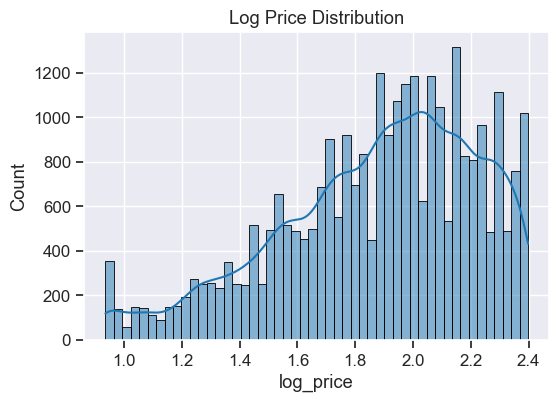

In [159]:
# Lý do: Extract để tạo categorical features mạnh, vì giá nhà phụ thuộc địa lý.

# Tạo log_price (vì price skew từ histogram)
df['log_price'] = np.log1p(df['price'])

# Plot log_price để check
plt.figure(figsize=(6, 4))
sns.histplot(df['log_price'], kde=True, bins=50)
plt.title('Log Price Distribution')
plt.show()

In [160]:
# 8. TRAIN_TEST_SPLIT (để tránh data leakage trong impute/feature eng)
# ========================
train_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

print(f"\nTrain: {len(train_df):,} | Test: {len(test_df):,}")


Train: 23,219 | Test: 5,805


In [161]:
# 9. XỬ LÝ MISSING VALUES (impute bằng median groupby district trên train)
# ========================
# Numerical impute
numerical_cols = ['area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']

district_medians = {}
for col in numerical_cols:
    if col in train_df.columns:
        district_medians[col] = train_df.groupby('district')[col].median().to_dict()
        overall_median = train_df[col].median()
        
        # Fill train
        train_df[col] = train_df.apply(
            lambda row: district_medians[col].get(row['district'], overall_median) if pd.isna(row[col]) else row[col],
            axis=1
        )
        train_df[col] = train_df[col].fillna(overall_median)
        
        # Fill test
        test_df[col] = test_df.apply(
            lambda row: district_medians[col].get(row['district'], overall_median) if pd.isna(row[col]) else row[col],
            axis=1
        )
        test_df[col] = test_df[col].fillna(overall_median)

# Categorical fill 'Missing'
categorical_cols = ['house_direction', 'legal_status', 'furniture_state']

for col in categorical_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].fillna('Missing')
        test_df[col] = test_df[col].fillna('Missing')

In [162]:
# Check missing sau impute
print("\n=== Missing sau impute (train) ===")
print(train_df.isnull().sum())


=== Missing sau impute (train) ===
area                     0
frontage                 0
access_road              0
house_direction          0
balcony_direction    19212
floors                   0
bedrooms                 0
bathrooms                0
legal_status             0
furniture_state          0
price                    0
city                     0
district                 0
log_price                0
dtype: int64


In [163]:
# === BƯỚC 10: FEATURE ENGINEERING (BỔ SUNG) ===

# Tính toán các đặc trưng trung bình theo quận (chỉ trên tập train để tránh data leakage)
district_stats = train_df.groupby('district').agg({
    'area': 'mean',
    'frontage': 'mean',
    'bedrooms': 'mean'
}).rename(columns={
    'area': 'district_avg_area',
    'frontage': 'district_avg_frontage',
    'bedrooms': 'district_avg_bedrooms'
})

# Merge các thông tin này vào tập train và test
train_df = train_df.merge(district_stats, on='district', how='left')
test_df = test_df.merge(district_stats, on='district', how='left')

# Fill NA cho các quận không có trong tập train (nếu có)
for col in district_stats.columns:
    overall_mean = train_df[col].mean()
    train_df[col].fillna(overall_mean, inplace=True)
    test_df[col].fillna(overall_mean, inplace=True)

# Tạo feature mới: Tỷ lệ so sánh diện tích của nhà so với diện tích trung bình của quận
for d in [train_df, test_df]:
    d['area_vs_district_avg'] = d['area'] / d['district_avg_area']
    # Bạn cũng có thể tạo các feature tương tự cho frontage, bedrooms...
    d['frontage_vs_district_avg'] = d['frontage'] / d['district_avg_frontage']
    
# Nhớ thêm các feature mới này vào danh sách `features` cho mô hình
features.extend(['area_vs_district_avg', 'frontage_vs_district_avg'])

In [164]:
# # Plot một số new features để check
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='area_x_district_avg', y='price', data=train_df)
# plt.title('Area x District Avg vs Price (Train)')
# plt.tight_layout()
# plt.show()

In [165]:
# 11. CHUẨN BỊ DATA CHO MODEL
# ========================
features = [
    'area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms',
    'total_rooms', 'bed_bath_ratio', 'area_per_floor', 'rooms_per_floor',
    'is_good_direction', 'district_avg_price_per_m2',
    'area_x_district_avg', 'frontage_x_access',
    'house_direction', 'legal_status', 'furniture_state',
    'city', 'district'
 ]

features = [f for f in features if f in train_df.columns]

X_train = train_df[features].copy()
y_train = train_df['log_price']

X_test = test_df[features].copy()
y_test = test_df['log_price']

# ========================
# 12. TRAIN CATBOOST
# ========================
cat_features = [f for f in features if f in cat_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostRegressor(
    iterations=7000,
    learning_rate=0.012,
    depth=10,
    l2_leaf_reg=6,
    random_seed=42,
    loss_function='RMSE',
    eval_metric='MAE',
    early_stopping_rounds=180,
    verbose=200,
    use_best_model=True
)

model.fit(
    train_pool,
    eval_set=test_pool,
)

0:	learn: 0.2784212	test: 0.2786412	best: 0.2786412 (0)	total: 89.5ms	remaining: 10m 26s
200:	learn: 0.1693730	test: 0.1685561	best: 0.1685561 (200)	total: 19.5s	remaining: 10m 59s
400:	learn: 0.1547888	test: 0.1558371	best: 0.1558371 (400)	total: 39s	remaining: 10m 41s
600:	learn: 0.1486173	test: 0.1514733	best: 0.1514733 (600)	total: 59.1s	remaining: 10m 29s
800:	learn: 0.1442509	test: 0.1489316	best: 0.1489316 (800)	total: 1m 19s	remaining: 10m 12s
1000:	learn: 0.1403227	test: 0.1469518	best: 0.1469518 (1000)	total: 1m 39s	remaining: 9m 56s
1200:	learn: 0.1369282	test: 0.1452216	best: 0.1452216 (1200)	total: 2m	remaining: 9m 41s
1400:	learn: 0.1341598	test: 0.1440576	best: 0.1440574 (1399)	total: 2m 21s	remaining: 9m 26s
1600:	learn: 0.1316906	test: 0.1430050	best: 0.1430050 (1600)	total: 2m 42s	remaining: 9m 9s
1800:	learn: 0.1294647	test: 0.1422489	best: 0.1422489 (1800)	total: 3m 4s	remaining: 8m 51s
2000:	learn: 0.1274255	test: 0.1416187	best: 0.1416187 (2000)	total: 3m 25s	rema

CatBoostRegressor(depth=10, early_stopping_rounds=180, eval_metric='MAE', iterations=7000, l2_leaf_reg=6, learning_rate=0.012, loss_function='RMSE', random_seed=42, use_best_model=True, verbose=200)

In [166]:
# 13. ĐÁNH GIÁ MODEL
# ========================
y_pred_log = model.predict(X_test)

print("\n=== Log Price Metrics ===")
print(f"MAE: {mean_absolute_error(y_test, y_pred_log):.5f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_log)):.5f}")
print(f"R²: {r2_score(y_test, y_pred_log):.5f}")

y_test_real = np.expm1(y_test)
y_pred_real = np.expm1(y_pred_log)

print("\n=== Giá thật (tỷ VND) ===")
print(f"MAE: {mean_absolute_error(y_test_real, y_pred_real):,.2f} tỷ")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_real, y_pred_real)):.2f} tỷ")
print(f"R²: {r2_score(y_test_real, y_pred_real):.4f}")

# Feature importance
fi = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False).head(15)

print("\n=== Top 15 features quan trọng nhất ===")
print(fi.to_string(index=False))


=== Log Price Metrics ===
MAE: 0.13592
RMSE: 0.18255
R²: 0.72109

=== Giá thật (tỷ VND) ===
MAE: 0.91 tỷ
RMSE: 1.23 tỷ
R²: 0.6746

=== Top 15 features quan trọng nhất ===
        feature  importance
           area   24.005005
       district   22.777636
           city   12.421161
         floors    8.898740
    access_road    7.412890
      bathrooms    6.147563
       frontage    4.238481
   legal_status    4.074551
furniture_state    3.816261
       bedrooms    3.552823
house_direction    2.654889


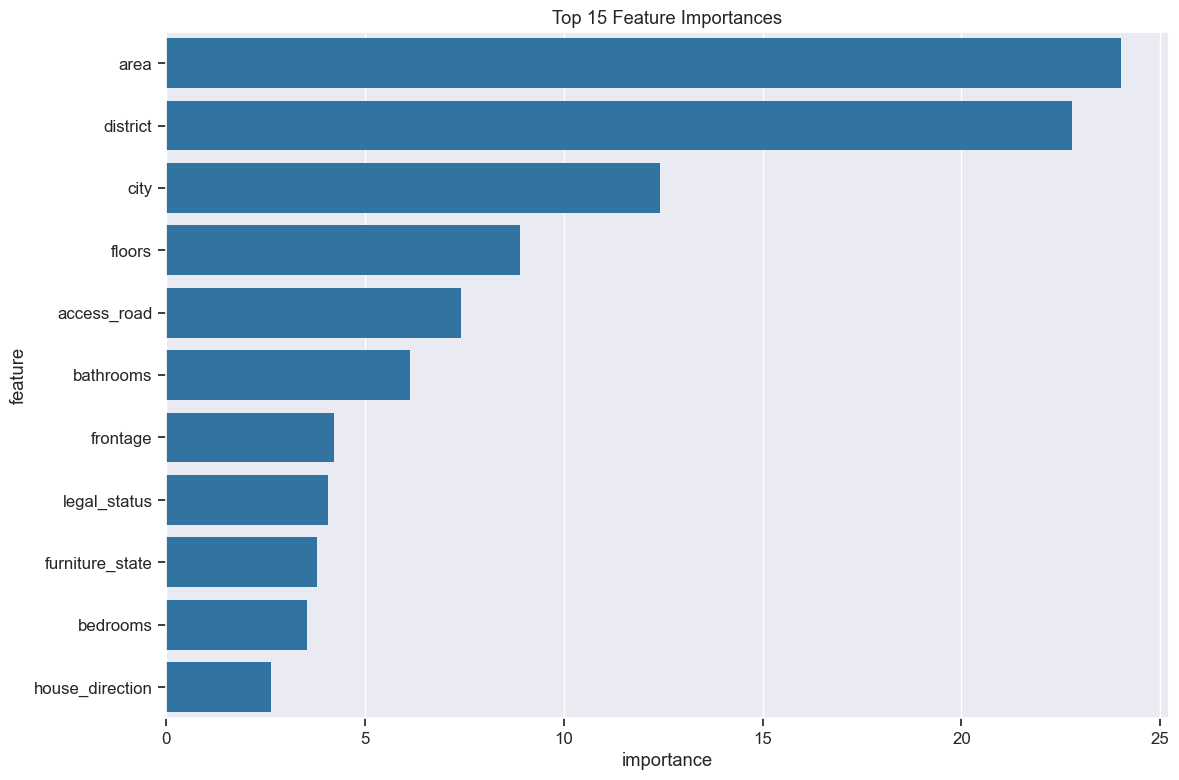

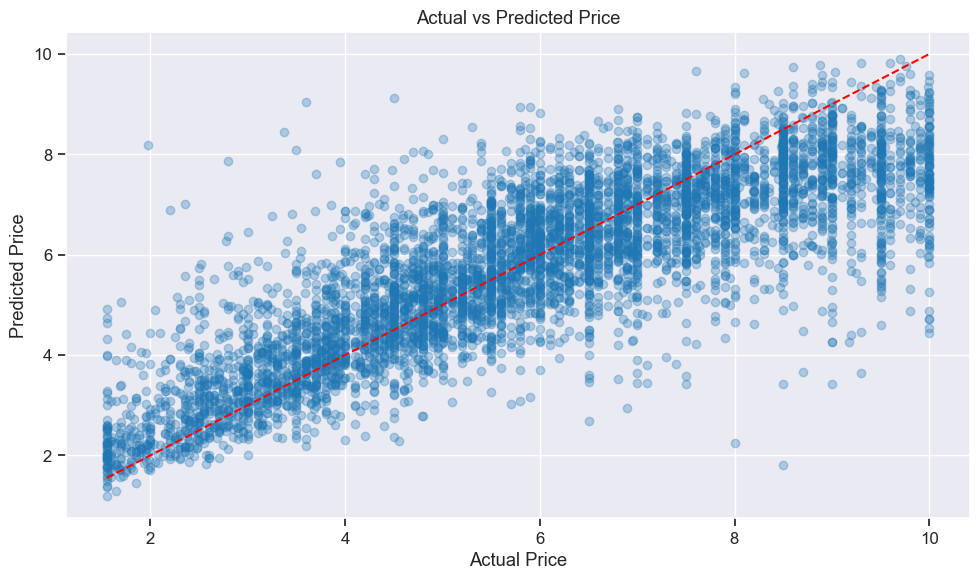

In [167]:
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=fi)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

# Plot predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_real, y_pred_real, alpha=0.3)
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.tight_layout()
plt.show()

In [171]:
# =============================================================================
# CELL TEST DỰ ĐOÁN GIÁ NHÀ (đã fix lỗi fillna categorical)
# =============================================================================

import pandas as pd
import numpy as np

# ── Dữ liệu test ──
test_input = {
    "area": 80,
    "address": "Đống Đa, Hà Nội",
    "bedrooms": 3,
    "bathrooms": 2,
    "floors": 4,
    "frontage": 6,
    "access_road": 5,
    "house_direction": "Nam",
    "legal_status": "Sổ hồng riêng",
    "furniture_state": "Nội thất đầy đủ"
}

df_test = pd.DataFrame([test_input])

df_test.columns = df_test.columns.str.strip().str.replace(' ', '_').str.lower()

for col in ['area', 'frontage', 'access_road', 'floors', 'bedrooms', 'bathrooms']:
    if col in df_test.columns:
        df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

if 'address' in df_test.columns:
    df_test['city'], df_test['district'] = zip(*df_test['address'].apply(extract_district_city_v2))
    df_test = df_test.drop(columns=['address'], errors='ignore')

for col in numerical_cols:
    if col in df_test.columns:
        df_test[col] = df_test.apply(
            lambda row: district_medians.get(col, {}).get(row.get('district', 'Other'), 
                                                          overall_medians.get(col, 0))
            if pd.isna(row[col]) else row[col],
            axis=1
        )

for col in ['house_direction', 'legal_status', 'furniture_state']:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna('Missing')

df_test['district_avg_price_per_m2'] = df_test['district'].map(district_avg).fillna(overall_avg)

df_test['total_rooms']      = df_test.get('bedrooms', 0).fillna(0) + df_test.get('bathrooms', 0).fillna(0) + 1
df_test['bed_bath_ratio']   = df_test.get('bedrooms', 0) / (df_test.get('bathrooms', 1) + 1e-6)
df_test['area_per_floor']   = df_test.get('area', 1) / (df_test.get('floors', 1) + 1e-6)
df_test['rooms_per_floor']  = df_test['total_rooms'] / (df_test.get('floors', 1) + 1e-6)
df_test['is_good_direction'] = df_test.get('house_direction', '').isin(good_dirs).astype(int)

df_test['area_x_district_avg'] = df_test.get('area', 0) * df_test['district_avg_price_per_m2']
df_test['frontage_x_access']   = df_test.get('frontage', 0) * df_test.get('access_road', 0)

X_test_input = df_test[features].copy()

for col in cat_cols:
    if col in X_test_input.columns:
        X_test_input[col] = X_test_input[col].astype('category')

# ── Fix fillna: xử lý riêng categorical và numeric ──
for col in X_test_input.columns:
    if X_test_input[col].dtype.name == 'category':
        # Thêm 'Missing' nếu chưa có và fill
        if 'Missing' not in X_test_input[col].cat.categories:
            X_test_input[col] = X_test_input[col].cat.add_categories('Missing')
        X_test_input[col] = X_test_input[col].fillna('Missing')
    else:
        X_test_input[col] = X_test_input[col].fillna(0)

# ── Dự đoán ──
pred_log = model.predict(X_test_input)
pred_price = np.expm1(pred_log)[0]

print("=== KẾT QUẢ DỰ ĐOÁN ===")
print(f"Input: {test_input}")
print(f"Dự đoán giá: {pred_price:,.2f} tỷ VND")
print(f"(giá log dự đoán: {pred_log[0]:.4f})")

=== KẾT QUẢ DỰ ĐOÁN ===
Input: {'area': 80, 'address': 'Đống Đa, Hà Nội', 'bedrooms': 3, 'bathrooms': 2, 'floors': 4, 'frontage': 6, 'access_road': 5, 'house_direction': 'Nam', 'legal_status': 'Sổ hồng riêng', 'furniture_state': 'Nội thất đầy đủ'}
Dự đoán giá: 5.24 tỷ VND
(giá log dự đoán: 1.8302)


In [169]:
# SAVE LẠI MODEL & PICKLE VỚI ĐƯỜNG DẪN GIỐNG .py
import pickle

MODEL_PATH = r'D:\batdongsan\RealEstate_HUCE\backend\AI_Model\catboost_model.cbm'
PICKLE_PATH = r'D:\batdongsan\RealEstate_HUCE\backend\AI_Model\preprocess_globals.pkl'

model.save_model(MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")

# Tính lại overall_medians từ train_df (đảm bảo mới nhất)
overall_medians = {col: train_df[col].median() for col in numerical_cols if col in train_df.columns}

globals_dict = {
    'district_medians': district_medians,
    'district_avg': district_avg,
    'overall_avg': overall_avg,
    'overall_medians': overall_medians,
    'features': features,
    'good_dirs': good_dirs,
    'numerical_cols': numerical_cols,
    'label_encoders': label_encoders,          # encode string → số
    'reverse_encoders': reverse_encoders       # số → string có dấu
}

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(globals_dict, f)

with open(PICKLE_PATH, 'wb') as f:
    pickle.dump(globals_dict, f)

print(f"Preprocess globals saved to {PICKLE_PATH}")
print("ĐÃ SAVE XONG - BẠN CÓ THỂ RESTART API VÀ TEST LẠI")

Model saved to D:\batdongsan\RealEstate_HUCE\backend\AI_Model\catboost_model.cbm
Preprocess globals saved to D:\batdongsan\RealEstate_HUCE\backend\AI_Model\preprocess_globals.pkl
ĐÃ SAVE XONG - BẠN CÓ THỂ RESTART API VÀ TEST LẠI
